In [4]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
from scipy.io import wavfile as wav
import IPython.display as ipd
import os
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
import tensorflow 
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Activation,Flatten
from tensorflow.keras.optimizers import Adam
from sklearn import metrics
from tensorflow.keras.callbacks import ModelCheckpoint
from datetime import datetime 

Data Loading

In [5]:
metadata = pd.read_csv('./UrbanSound8K/metadata/UrbanSound8K.csv')
audio_dataset_path = './UrbanSound8K/audio/'
metadata.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [6]:
fold= metadata['classID']
fold.value_counts()
name= metadata['class']
name.value_counts()

class
dog_bark            1000
children_playing    1000
air_conditioner     1000
street_music        1000
engine_idling       1000
jackhammer          1000
drilling            1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64

In [7]:
sample_data= './UrbanSound8K/audio/fold2/4201-3-0-0.wav'

EDA (Exploratory Data Analysis)

Text(0.5, 1.0, 'Waveform of Sample Audio using wavfile')

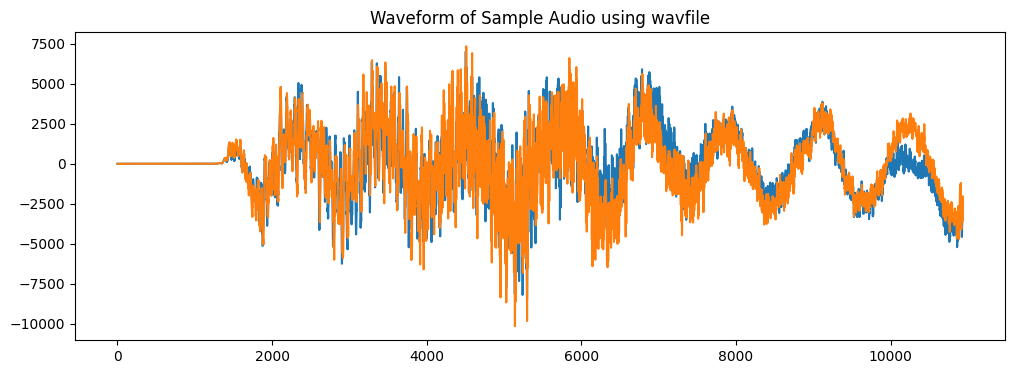

In [8]:
wav_rate, wav_data = wav.read(sample_data)
# wav_data_float = wav_data.astype(np.float32) / np.iinfo(wav_data.dtype).max
# librosa.display.waveshow(wav_data_float, sr=wav_freq)
# plt.plot(wav_data)
# plt.show()
plt.figure(figsize=(12, 4))
plt.plot(wav_data)
plt.title('Waveform of Sample Audio using wavfile')

In [ ]:
print(wav_rate, wav_data.shape )

44100 (14004, 2)


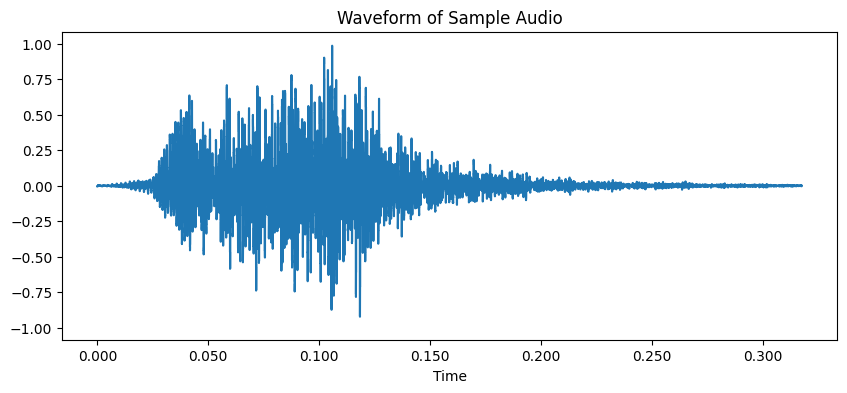

In [ ]:
plt.figure(figsize=(10, 4))
data, sample_rate = librosa.load(sample_data)
librosa.display.waveshow(data, sr=sample_rate)
plt.title('Waveform of Sample Audio')
ipd.Audio(sample_data)

In [ ]:
print('sample_data:',data,'\n sample_rate:', sample_rate)

sample_data: [-0.00347107 -0.00501926 -0.00465448 ... -0.00248442 -0.00154777
 -0.00035547] 
 sample_rate: 22050


Feature Selection

In [ ]:
def mfccs(data, sample_rate):
    mfccs= librosa.feature.mfcc(y=data, sr=sample_rate, n_mfcc=13)
    mfccs = np.mean(mfccs.T, axis=0)
    return mfccs

In [ ]:
def features_extractor(file_path):
    data, sample_rate = librosa.load(file_path)
    mfccs_feature = mfccs(data, sample_rate)
    return mfccs_feature

In [ ]:
extraced_features = []
for index, row in tqdm(metadata.iterrows()):
    file_path = os.path.join(audio_dataset_path, 'fold' + str(row['fold']), row['slice_file_name'])
    class_label = row['class']
    data = features_extractor(file_path)
    extraced_features.append([data, class_label])

3550it [01:09, 51.28it/s]c:\Users\gargs\AppData\Local\Programs\Python\Python39\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
8322it [03:19, 66.16it/s]c:\Users\gargs\AppData\Local\Programs\Python\Python39\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
c:\Users\gargs\AppData\Local\Programs\Python\Python39\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
8732it [03:27, 42.10it/s]


In [ ]:
extraced_features_df= pd.DataFrame(extraced_features, columns=['feature', 'class'])
extraced_features_df.head()

,feature,class
0,"[-211.93698, 62.581207, -122.81315, -60.745293...",dog_bark
1,"[-417.0052, 99.336624, -42.995586, 51.073326, ...",children_playing
2,"[-452.39316, 112.36253, -37.578068, 43.19586, ...",children_playing
3,"[-406.47922, 91.1966, -25.043556, 42.78452, 11...",children_playing
4,"[-439.63873, 103.86223, -42.658787, 50.690277,...",children_playing


In [ ]:
print(extraced_features_df)

                                                feature             class
0     [-211.93698, 62.581207, -122.81315, -60.745293...          dog_bark
1     [-417.0052, 99.336624, -42.995586, 51.073326, ...  children_playing
2     [-452.39316, 112.36253, -37.578068, 43.19586, ...  children_playing
3     [-406.47922, 91.1966, -25.043556, 42.78452, 11...  children_playing
4     [-439.63873, 103.86223, -42.658787, 50.690277,...  children_playing
...                                                 ...               ...
8727  [-391.3721, 125.36239, -40.634056, 25.899754, ...          car_horn
8728  [-339.42715, 76.409096, -35.30988, 41.984035, ...          car_horn
8729  [-297.31534, 102.09026, -36.75108, 26.816488, ...          car_horn
8730  [-336.92386, 115.313896, -44.8471, 24.968985, ...          car_horn
8731  [-307.4176, 83.30673, -25.756512, 35.44811, 4....          car_horn

[8732 rows x 2 columns]


In [ ]:
X= np.array(extraced_features_df['feature'].tolist())
y= np.array(extraced_features_df['class'].tolist())

In [ ]:
# y = np.array(pd.get_dummies(y))
label_encoder= LabelEncoder()
y = to_categorical(label_encoder.fit_transform(y))
y.shape

(8732, 10)

In [ ]:
#Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (6985, 13) (6985, 10)
Testing set shape: (1747, 13) (1747, 10)


Model Creation

In [ ]:
### No of classes
num_labels=y.shape[1]

In [ ]:
model=Sequential()
###first layer
model.add(Dense(100,input_shape=(13,)))
model.add(Activation('relu'))
model.add(Dropout(0.5))
###second layer
model.add(Dense(200))
model.add(Activation('relu'))
model.add(Dropout(0.5))
###third layer
model.add(Dense(100))
model.add(Activation('relu'))
model.add(Dropout(0.5))

###final layer
model.add(Dense(num_labels))
model.add(Activation('softmax'))

In [ ]:
# model.summary()

In [ ]:
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

In [ ]:
#Model Training

num_epochs = 100
num_batch_size = 32

checkpointer = ModelCheckpoint(filepath='saved_models/audio_classification.hdf5', 
                               verbose=1, save_best_only=True)
start = datetime.now()

model.fit(X_train, y_train, batch_size=num_batch_size, epochs=num_epochs, validation_data=(X_test, y_test), callbacks=[checkpointer], verbose=1)


duration = datetime.now() - start
print("Training completed in time: ", duration)

Epoch 1/100
206/219 [===========================>..] - ETA: 0s - loss: 12.2036 - accuracy: 0.1147
Epoch 1: val_loss improved from inf to 2.29305, saving model to saved_models\audio_classification.hdf5
219/219 [==============================] - 3s 7ms/step - loss: 11.6802 - accuracy: 0.1154 - val_loss: 2.2930 - val_accuracy: 0.1214
Epoch 2/100
217/219 [============================>.] - ETA: 0s - loss: 2.5308 - accuracy: 0.1142
Epoch 2: val_loss improved from 2.29305 to 2.27802, saving model to saved_models\audio_classification.hdf5
219/219 [==============================] - 1s 5ms/step - loss: 2.5295 - accuracy: 0.1144 - val_loss: 2.2780 - val_accuracy: 0.1202
Epoch 3/100
215/219 [============================>.] - ETA: 0s - loss: 2.3418 - accuracy: 0.1173
Epoch 3: val_loss improved from 2.27802 to 2.26923, saving model to saved_models\audio_classification.hdf5
219/219 [==============================] - 1s 5ms/step - loss: 2.3411 - accuracy: 0.1168 - val_loss: 2.2692 - val_accuracy: 0.11

In [ ]:
test_accuracy=model.evaluate(X_test,y_test,verbose=0)
print(test_accuracy[1])

0.6645678281784058


In [ ]:
filename = features_extractor('./UrbanSound8K/audio/fold1/14113-4-0-1.wav')
prediction_feature = filename.reshape(1, -1)
prediction_probs = model.predict(prediction_feature)
prediction = np.argmax(prediction_probs, axis=1)
predicted_class = label_encoder.inverse_transform(prediction)
print("Predicted class:", predicted_class[0])

1/1 [==============================] - 0s 200ms/step
Predicted class: street_music
